# Lasso Regression

## Import Required Libraries

In [1]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import os
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold


## Load Engineered Features

In [2]:
df = pd.read_csv('../feature_engineering.csv')

In [3]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

X = df[feature_columns]
y = df['fk_estimated_uk_age_num']

## Model Training and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=456
)

## Hyperparameter Tuning with GridSearchCV

In [5]:
alphas = np.arange(0.01, 10, 0.1)
param_grid = {'alpha': alphas}
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

lasso = Lasso(max_iter=20000, random_state=4)
grid_lasso = GridSearchCV(lasso, param_grid, cv=cv, scoring='r2', verbose=1, n_jobs=-1)
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

Fitting 30 folds for each of 100 candidates, totalling 3000 fits


## Save the Trained Model

In [6]:
joblib.dump(best_lasso, f'../../models/lasso_regression.joblib')

['../../models/lasso_regression.joblib']

## Evaluate Results

In [7]:
y_pred = best_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print("MSE:", mse)
print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

y_train_pred = best_lasso.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R^2: {r2_train:.2f}")
print(f"Test MAE: {mae:.2f}, Test R^2: {r2:.2f}")

MAE: 0.25
MSE: 0.09005396682910853
RMSE: 0.30
R^2 Score: 1.00
Train MAE: 0.26, Train R^2: 1.00
Test MAE: 0.25, Test R^2: 1.00


In [8]:
results = {
    'Model': 'Lasso Regression',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'Params': str(grid_lasso.best_params_),
    'Notes': ''
}

In [9]:
results_file = '../all_model_results.csv'

# Turn the results dict into a DataFrame row
df_result = pd.DataFrame([results])

# If file exists, append without headers; else, create with headers
if os.path.isfile(results_file):
    df_result.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_result.to_csv(results_file, index=False)

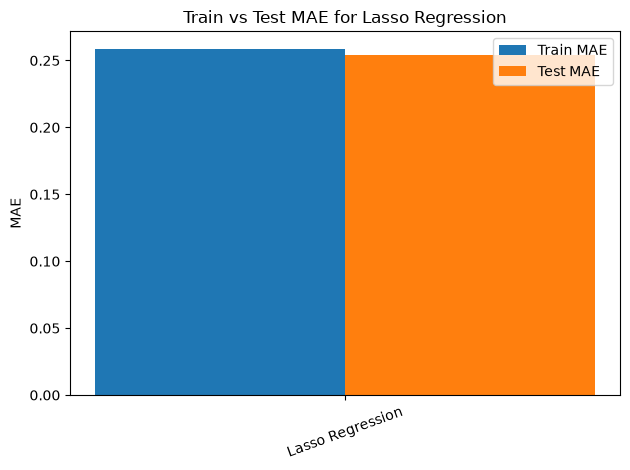

In [10]:
# Visualize train vs test MAE for the Lasso model

models = ['Lasso Regression']
train_mae = [mae_train]
test_mae = [mae]

x = range(len(models))
plt.bar(x, train_mae, width=0.4, label='Train MAE')
plt.bar([i + 0.4 for i in x], test_mae, width=0.4, label='Test MAE')

plt.xticks([i + 0.2 for i in x], models, rotation=20)
plt.ylabel('MAE')
plt.title('Train vs Test MAE for Lasso Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Visualisation

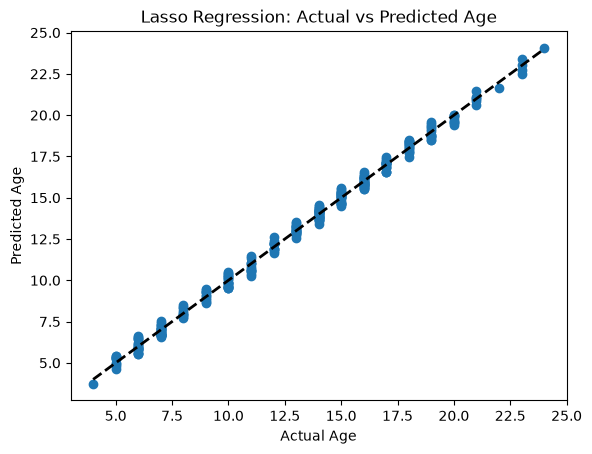

In [11]:
# Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Lasso Regression: Actual vs Predicted Age")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

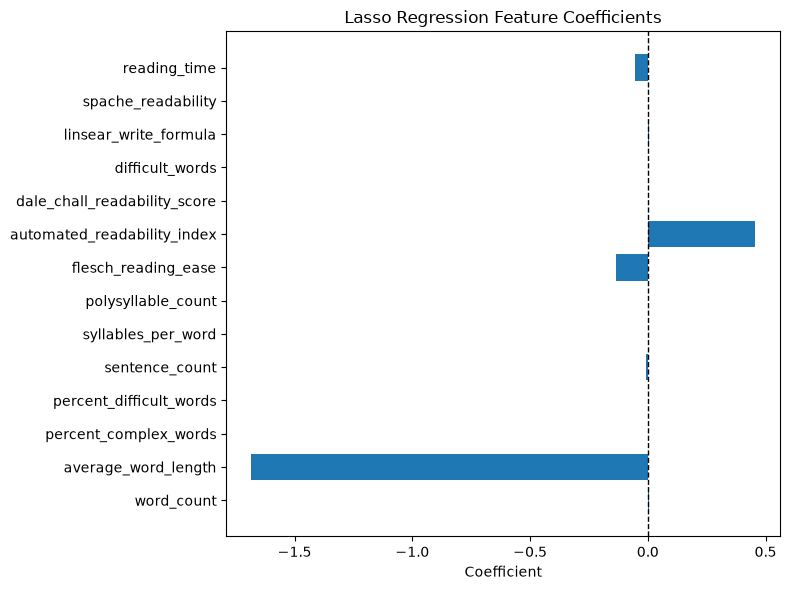

In [12]:
coefs = pd.DataFrame({
	"Feature": feature_columns,
	"Lasso": best_lasso.coef_
})

plt.figure(figsize=(8, 6))
plt.barh(coefs["Feature"], coefs["Lasso"])
plt.title("Lasso Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()